In [ ]:
import sys
sys.path.append("../../Resource/")
print(sys.path)

In [ ]:
import h5py, os, argparse, logging, time

import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader

from DGS.Model.Publications import DeepSEA


/share/home/zhanglab/user/lijiaqi/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/share/home/zhanglab/user/lijiaqi/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [ ]:
os.makedirs("./Log", exist_ok=True)
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(filename)s[line:%(lineno)d] %(levelname)s %(message)s',
                    datefmt='%a, %d %b %Y %H:%M:%S',
                    filename=time.strftime('./Log/log_DGS_deepsea.%m%d.%H:%M:%S.txt'),
                    filemode='w')
logging.info(sys.path)

# args
parser = argparse.ArgumentParser()
parser.add_argument("data")
parser.add_argument("--gpu-device", dest="device_id", default="0")
args = parser.parse_args(['../Dataset/Dataset.DeepSEA_919features.h5', 
                          '--gpu-device', '3'])
logging.info(args)


In [4]:
## change device
os.environ["CUDA_VISIBLE_DEVICES"] = args.device_id
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Prepare dataset

1. unpack the h5file datasets
2. generate the DataLoader

In [6]:
# unpack datasets
h5file = h5py.File(args.data, 'r')
anno = h5file["annotation"][:]
x_test = h5file["test_data"][:5120].astype(np.float32)
y_test = h5file["test_label"][:5120].astype(np.float32)
h5file.close()

# unpack anno
n_tasks = anno.shape[0]

y_test.shape

(5120, 919)

In [7]:
task_names = pd.read_csv("../../PHD_works/DeepZJ/pretrain_deepSea/data/DeepSEA.metric.tsv", sep='\t')
task_names.head()

,Cell Type,TF/DNase/HistoneMark,Treatment,Original File Name,AUC,AUPRC,AUPRC Baseline
0,8988T,DNase,NaN,wgEncodeAwgDnaseDuke8988tUniPk.narrowPeak.gz,0.910351436,0.401035,0.039589
1,AoSMC,DNase,NaN,wgEncodeAwgDnaseDukeAosmcUniPk.narrowPeak.gz,0.924485649,0.439494,0.041031
2,Chorion,DNase,NaN,wgEncodeAwgDnaseDukeChorionUniPk.narrowPeak.gz,0.896293207,0.320603,0.031379
3,CLL,DNase,NaN,wgEncodeAwgDnaseDukeCllUniPk.narrowPeak.gz,0.928261659,0.358980,0.021120
4,Fibrobl,DNase,NaN,wgEncodeAwgDnaseDukeFibroblUniPk.narrowPeak.gz,0.837919632,0.340633,0.058138


In [8]:
# define data loader
batch_size = 512
test_loader = DataLoader(list(zip(x_test, y_test)), batch_size=batch_size, 
                            shuffle=False, num_workers=0, drop_last=False, pin_memory=True)

## Define DeepSEA model
Initialized DeepSEA architectures in DGS

In [9]:
# define model
model = DeepSEA(sequence_length=x_test.shape[-1], n_genomic_features=n_tasks)
model.to(device)

DeepSEA(
  (conv_net): Sequential(
    (0): Conv1d(4, 320, kernel_size=(8,), stride=(1,))
    (1): ReLU(inplace=True)
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(320, 480, kernel_size=(8,), stride=(1,))
    (5): ReLU(inplace=True)
    (6): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(480, 960, kernel_size=(8,), stride=(1,))
    (9): ReLU(inplace=True)
    (10): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=50880, out_features=919, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=919, out_features=919, bias=True)
    (3): Sigmoid()
  )
)

In [ ]:
params = torch.load("../2_DGS_CaseStudy_DeepSEA/DGS_DeepSEA_DeepSEA/Log/best_model.pth")
model.load_state_dict(params, strict=True)

<All keys matched successfully>

## Variant Effect Prediction
### VEP

In [25]:
genome_filename = "../../Resource/Reference/Human_hg19/Homo_sapiens.GRCh37.dna.toplevel.fa.gz"

In [32]:
bcf_filename = "../Dataset/VEP_data/lt0.05.vcf"

variant_df = pd.read_csv(bcf_filename, comment="#", sep='\t', header=None)
variant_df.columns = ['chrom', 'pos1', 'id', 'ref', 'alt']
variant_df['chrom'] = variant_df['chrom'].str.replace("chr",'')
variant_df['pos0'] = variant_df['pos1'] - 1
variant_df = variant_df[variant_df['ref'].apply(lambda x:len(x))==1]
variant_df = variant_df[variant_df['alt'].apply(lambda x:len(x))==1]

P_diff = []
for _, variant_info in tqdm(variant_df.iterrows()):
    pos = variant_info.pos0
    var_centred_interval = {'chrom':variant_info.chrom, 'start':pos-500, 'end':pos+500}
    seq_ref = fetch_seq_interval(genome_filename, var_centred_interval)
    check_reference(variant_info, seq_ref)

    seq_alt = mutate_varseq_from_ref(variant_info, seq_ref)

    p_diff = vep(model, seq_ref, seq_alt)
    P_diff.append(p_diff)

P_diff = np.concatenate(P_diff, axis=0)
P_diff = np.abs(P_diff)
P_diff.shape, variant_df.shape

((1232941, 690), (1253557, 6))

In [33]:
variant_df.reset_index().to_csv("VEP/variant_df.lt0.05.csv")
task_names.reset_index().to_csv("VEP/task_names.lt0.05.csv")
np.savez_compressed("VEP/P_diff.lt0.05.npz", data=P_diff)

In [36]:
bcf_filename = "../Dataset/VEP_data/gt0.50.vcf"

variant_df = pd.read_csv(bcf_filename, comment="#", sep='\t', header=None)
variant_df.columns = ['chrom', 'pos1', 'id', 'ref', 'alt']
variant_df['chrom'] = variant_df['chrom'].str.replace("chr",'')
variant_df['pos0'] = variant_df['pos1'] - 1
variant_df = variant_df[variant_df['ref'].apply(lambda x:len(x))==1]
variant_df = variant_df[variant_df['alt'].apply(lambda x:len(x))==1]

P_diff = []
for _, variant_info in tqdm(variant_df.iterrows()):
    pos = variant_info.pos0
    var_centred_interval = {'chrom':variant_info.chrom, 'start':pos-500, 'end':pos+500}
    seq_ref = fetch_seq_interval(genome_filename, var_centred_interval)
    check_reference(variant_info, seq_ref)

    seq_alt = mutate_varseq_from_ref(variant_info, seq_ref)

    p_diff = vep(model, seq_ref, seq_alt)
    P_diff.append(p_diff)

P_diff = np.concatenate(P_diff, axis=0)
P_diff = np.abs(P_diff)
P_diff.shape, variant_df.shape

((9919499, 690), (11389084, 6))

In [37]:
variant_df.reset_index().to_csv("VEP/variant_df.gt0.05.csv")
task_names.reset_index().to_csv("VEP/task_names.gt0.05.csv")
np.savez_compressed("VEP/P_diff.gt0.05.npz", data=P_diff)

In [44]:
%%time

nonsig_variant_df = pd.read_csv("VEP/variant_df.gt0.05.csv")
nonsig_P_diff = np.load("VEP/P_diff.gt0.05.npz")['data']

nonsig_vep_df = pd.concat([variant_df.iloc[:P_diff.shape[0]].reset_index(), pd.DataFrame(P_diff)], axis=1)
nonsig_vep_df.shape

CPU times: user 2min 27s, sys: 8.2 s, total: 2min 35s
Wall time: 2min 36s


(1232941, 699)

In [45]:
%%time

sig_variant_df = pd.read_csv("VEP/variant_df.lt0.05.csv")
sig_P_diff = np.load("VEP/P_diff.lt0.05.npz")['data']

sig_vep_df = pd.concat([variant_df.iloc[:P_diff.shape[0]].reset_index(), pd.DataFrame(P_diff)], axis=1)
sig_vep_df.shape

CPU times: user 1min 50s, sys: 34.5 s, total: 2min 24s
Wall time: 2min 25s


(1232941, 699)

In [46]:
nonsig_vep_test = np.random.choice(nonsig_P_diff[:5000].flatten(), 1000)
sig_vep_test = np.random.choice(sig_P_diff[:5000].flatten(), 1000)

<Axes: ylabel='Count'>

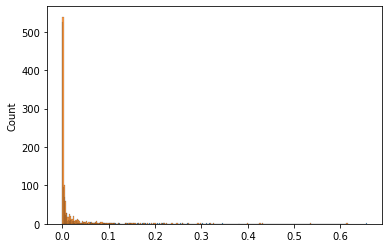

In [47]:
import seaborn as sns
sns.histplot(nonsig_vep_test)
sns.histplot(sig_vep_test)

<Axes: xlabel='variable', ylabel='value'>

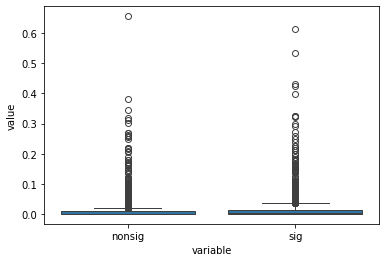

In [48]:
results = pd.DataFrame({"nonsig":nonsig_vep_test, "sig":sig_vep_test}).melt()
sns.boxplot(results, x="variable", y="value")

In [49]:
features = range(sig_P_diff.shape[-1])
sig_scores_matrix = sig_P_diff
nonsig_scores_matrix = nonsig_P_diff

In [50]:
feature_pvalues = compute_feature_mannwhitneyu(
    features, nonsig_scores_matrix, sig_scores_matrix)

In [51]:
from statsmodels.sandbox.stats.multicomp import multipletests

features_ordered, pvalues = zip(*feature_pvalues.items())
below_alpha, qvalues, _, _ = multipletests(
    pvalues, alpha=0.05, method="fdr_bh", is_sorted=False)
below_alpha_indices = [ix for ix, a in enumerate(below_alpha) if a]
print("FDR adjustment: {0} features below alpha = 0.05".format(
    len(below_alpha_indices)))


FDR adjustment: 669 features below alpha = 0.05


In [59]:
metric = task_names.iloc[:, :3]
metric['pval'] = [feature_pvalues[k] for k in feature_pvalues]
metric['qval'] = qvalues
metric.to_csv("VEP/task_names_qval.csv")